In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import sinter
import matplotlib.pyplot as plt
import os
import pickle
import numpy as np
import plotly.graph_objects as go

from matplotlib.tri import Triangulation
from mpl_toolkits.mplot3d import Axes3D

from qecsim.xzzx_code.circuit import XZZX_code
from qecsim.threshold_num.calc_threshold import threshold_approx
from qecsim.threshold_num.calc_threshold_new import calc_threshold_new

In [3]:
#Loading Stats with pickle
with open("XZZX_num_value(full_bias)_new.pkl", "rb") as file:
    num_value = pickle.load(file)
with open("XZZX_num_value(full_bias_low_d).pkl", "rb") as file:
    num_value_low = pickle.load(file)
with open("XZZX_num_value(full_bias_low_d_new_method).pkl", "rb") as file:
    num_value_low_nm = pickle.load(file)

In [18]:
np.set_printoptions(threshold=np.inf)  # no truncation
array_raw = np.array([coord + [val] for coord, val in num_value])
array_low_raw = np.array([coord + [val] for coord, val in num_value_low])
array_low_nm_raw = np.array([coord + [val] for coord, val in num_value_low_nm])
array_low = np.array([coord + [val] for coord, val in num_value_low if coord not in [[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]]])
array_low_nm = np.array([coord + [val] for coord, val in num_value_low_nm if val != -1])

In [34]:
###########################################
# Define probabilites and threshold vectors
###########################################

pX, pY, pZ = array_raw[:,0], array_raw[:,1], array_raw[:,2]
p_c = array_raw[:,3]

######################
# 2.  Diagnostic check
######################

bad = (pX < 0) | (pZ < 0) | (pY < 0)
if bad.any():
    print("Found", bad.sum(), "rows outside the simplex; they are being dropped.")
    pX, pZ, pY, p_c = [v[~bad] for v in (pX, pZ, pY, p_c)]

assert pX.size > 0, "No valid rows remain inside the simplex!"

# ---------------------------------------------------------------
# 3.  Barycentric → Cartesian
x = pX + 0.5*pY
y = (np.sqrt(3)/2)*pY
z = p_c

# ---------------------------------------------------------------
# 4.  Triangulate & plot (identical to before)
tri = Triangulation(x, y)
i, j, k = tri.triangles.T

mesh = go.Mesh3d(
    x=x, y=y, z=z,
    i=i, j=j, k=k,
    intensity=z, colorscale="plasma", flatshading=True,
    colorbar=dict(title="p<sub>c</sub>", thickness=18, x=1.08)
)

base = go.Mesh3d(
    x=[0, 1, 0.5], y=[0, 0, np.sqrt(3)/2], z=[0, 0, 0],
    i=[0], j=[1], k=[2],
    color="lightgrey", opacity=0.5, showscale=False
)

labels = go.Scatter3d(
    x=[0, 1, 0.5], y=[0, 0, np.sqrt(3)/2], z=[0, 0, 0],
    mode="text", text=["Z", "X", "Y"],
    textfont=dict(size=16), showlegend=False
)

fig = go.Figure([mesh, base, labels])
fig.update_layout(
    scene=dict(
        xaxis_title="X", yaxis_title="Z",
        zaxis_title="Threshold error rate  p<sub>c</sub>",
        zaxis_range=[0, 0.55],
        camera=dict(eye=dict(x=1.5, y=0.9, z=0.7))
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    width=640, height=500
)
fig.show()

In [12]:
###########################################
# Define probabilites and threshold vectors
###########################################

pX, pY, pZ = array_low_nm[:,0], array_low_nm[:,1], array_low_nm[:,2]
p_c = array_low_nm[:,3]

######################
# 2.  Diagnostic check
######################

bad = (pX < 0) | (pZ < 0) | (pY < 0)
if bad.any():
    print("Found", bad.sum(), "rows outside the simplex; they are being dropped.")
    pX, pZ, pY, p_c = [v[~bad] for v in (pX, pZ, pY, p_c)]

assert pX.size > 0, "No valid rows remain inside the simplex!"

# ---------------------------------------------------------------
# 3.  Barycentric → Cartesian
x = pX + 0.5*pY
y = (np.sqrt(3)/2)*pY
z = p_c

# ---------------------------------------------------------------
# 4.  Triangulate & plot (identical to before)
tri = Triangulation(x, y)
i, j, k = tri.triangles.T

mesh = go.Mesh3d(
    x=x, y=y, z=z,
    i=i, j=j, k=k,
    intensity=z, colorscale="plasma", flatshading=True,
    colorbar=dict(title="p<sub>c</sub>", thickness=18, x=1.08)
)

base = go.Mesh3d(
    x=[0, 1, 0.5], y=[0, 0, np.sqrt(3)/2], z=[0, 0, 0],
    i=[0], j=[1], k=[2],
    color="lightgrey", opacity=0.5, showscale=False
)

labels = go.Scatter3d(
    x=[0, 1, 0.5], y=[0, 0, np.sqrt(3)/2], z=[0, 0, 0],
    mode="text", text=["Z", "X", "Y"],
    textfont=dict(size=16), showlegend=False
)

fig = go.Figure([mesh, base, labels])
fig.update_layout(
    scene=dict(
    xaxis_title="X",
    yaxis_title="Z",
    zaxis_title="Threshold error rate  p<sub>c</sub>",
    zaxis=dict(range=[0, 0.07]),
    camera=dict(eye=dict(x=1.5, y=0.9, z=0.7))
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    width=640, height=500
)
fig.show()


In [35]:
###################################################
# Number of zero entries -> Still wrong approx here
###################################################

count_pt_zeros = 0

for bx, by, bz, pt in array_raw:
    if pt == -1:
        count_pt_zeros += 1

count_pt_zeros

0

In [28]:
XZZX_code(
        distance = 3,
        rounds = 3, 
        state_init ="Ver",
        noise_bias = [0.0, 0.0, 1.0],
        after_c_pauli_channel_prob = 0.2
        )

[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0]


stim.Circuit('''
    QUBIT_COORDS(0, 2) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(1, 3) 2
    QUBIT_COORDS(1, 5) 3
    QUBIT_COORDS(2, 2) 4
    QUBIT_COORDS(2, 4) 5
    QUBIT_COORDS(2, 6) 6
    QUBIT_COORDS(3, 1) 7
    QUBIT_COORDS(3, 3) 8
    QUBIT_COORDS(3, 5) 9
    QUBIT_COORDS(4, 0) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(4, 4) 12
    QUBIT_COORDS(5, 1) 13
    QUBIT_COORDS(5, 3) 14
    QUBIT_COORDS(5, 5) 15
    QUBIT_COORDS(6, 4) 16
    R 2 7 9 14 4 5 11 12 0 16 10 6
    RX 1 3 8 13 15
    TICK
    H 4 5 11 12 0 16 10 6
    PAULI_CHANNEL_1(0, 0, 0.2) 4 5 11 12 0 16 10 6
    TICK
    CX 4 1 5 2 11 7 12 8 16 14 6 3
    PAULI_CHANNEL_2(0, 0, 0.0666667, 0, 0, 0, 0, 0, 0, 0, 0, 0.0666667, 0, 0, 0.0666667) 4 1 5 2 11 7 12 8 16 14 6 3
    TICK
    CZ 4 7 5 8 11 13 12 14 16 15 6 9
    TICK
    CZ 4 2 5 3 11 8 12 9 0 1 10 7
    TICK
    CX 4 8 5 9 11 14 12 15 0 2 10 13
    PAULI_CHANNEL_2(0, 0, 0.0666667, 0, 0, 0, 0, 0, 0, 0, 0, 0.0666667, 0, 0, 0.0666667) 4 8 5 9 11 14 12 15 0 2 10

In [32]:
# Running simulation
task_noisy_v = [sinter.Task(
    circuit = XZZX_code(
        distance = d,
        rounds = d, 
        state_init ="Ver",
        noise_bias = [0.0, 0.0, 1.0],
        after_c_pauli_channel_prob = noise
        ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [i for i in np.arange(0.005, 0.1, 0.005)]
    for d in [7, 9]
]


stats_noisy_v : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_v,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=10_000,
    print_progress=True
)

Starting 64 workers...
38 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                    
        1 pymatching <1m    4997679       10000 p=0.005,distance=7               
        1 pymatching   ?    5000000       10000 p=0.005,distance=9               
        1 pymatching   ?    5000000       10000 p=0.01,distance=7                
        1 pymatching   ?    5000000       10000 p=0.01,distance=9                
        1 pymatching   ?    5000000       10000 p=0.015,distance=7               
        1 pymatching   ?    5000000       10000 p=0.015,distance=9               
        1 pymatching   ?    5000000       10000 p=0.02,distance=7                
        1 pymatching   ?    5000000       10000 p=0.02,distance=9                
        1 pymatching   ?    5000000       10000 p=0.025,distance=7               
        1 pymatching   ?    5000000       10000 p=0.025,distance=9               
        1 pymatching   ?    5000000       10000 p=0.03000000

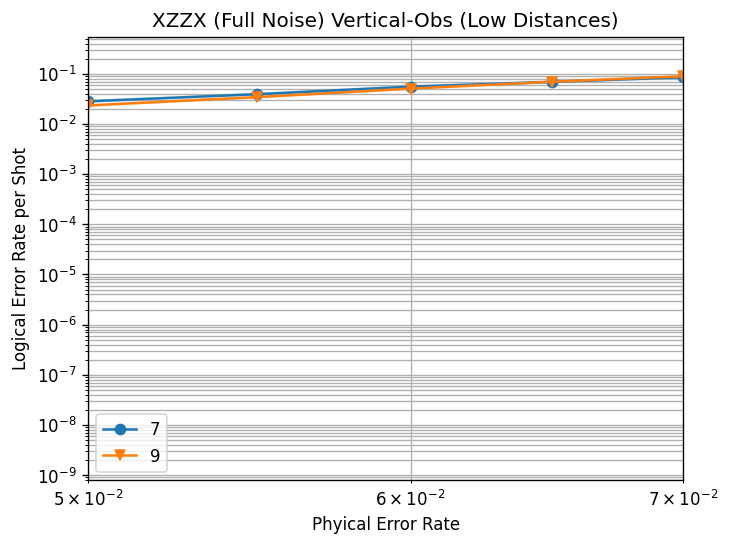

In [38]:
######################################
# Plotting Noise (Vertical Observable)
######################################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy_v,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(0.05, 0.07)
ax.set_title("XZZX (Full Noise) Vertical-Obs (Low Distances)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [37]:
calc_threshold_new(stats_noisy_v)

0.06460623434668124